# Python Tools for LP

CHBE444: Design I, Prof. Ganesh Sriram (gsriram@umd.edu), University of Maryland.

## Python Packages: NumPy, SciPy, SymPy, CHBE444UMD

This course introduces several Python packages useful for computation:

+ [NumPy](https://numpy.org) is a powerful package for performing numerical computation, which supports vectors and matrices, and offers smart ways of working with them;
+ [SciPy](https://scipy.org) provides tools for scientific and technical computing including optimization;
+ [SymPy](https://www.sympy.org) facilitates symbolic mathematics;
+ [GAMSPy](https://gamspy.readthedocs.io/en/latest/index.html) enables use of the General Algebraic Modeling System (GAMS), a powerful language for modeling and optimization, within Python;
+ [IPython](https://ipython.org/) facilitates interactive and rich displays, especially within Jupyter;
+ [CHBE444UMD](https://pypi.org/project/chbe444umd), offers ChE design utilities for this course.

In this workshop, we will use some of these packages for visualizing, processing and solving LPs.

These packages can be installed by using `pip` from within Jupyter:

```
%pip install numpy
%pip install scipy
%pip install sympy
%pip install gamspy
%pip install IPython
%pip install chbe444umd
```

You may need to upgrade packages every once in a while. To upgrade, use:

```
%pip install chbe444umd --upgrade
```

Remember to restart the kernel after you install or upgrade a package.

## Introduction to SymPy

In [1]:
import sympy as sym
import IPython.display as ipd

x, y = sym.symbols('x y')  # define symbols
# left x, y: what Python calls them; right x, y: how they are displayed

y = (x - 4)**3  # define a symbolic expression
print(y)  # print the expression
ipd.display(ipd.Math(sym.latex(y)))  # print the expression using LaTeX
ipd.display(y)  # shortcut for the above

(x - 4)**3


<IPython.core.display.Math object>

(x - 4)**3

In [2]:
print(sym.expand(y))  # expand the expression
sym.pprint(sym.expand(y))  # pretty-print the expanded expression
ipd.display(sym.expand(y))  # expanded expression using LaTeX

x**3 - 12*x**2 + 48*x - 64
 3       2            
x  - 12⋅x  + 48⋅x - 64


x**3 - 12*x**2 + 48*x - 64

## Throughput Analysis for Urea LP on SymPy

We will first use matrices in SymPy to perform a throughput analysis of the urea LP we studied in this course. First, we set up a _stoichiometric matrix_ $\mathbf{S}$ containing the stoichiometric coefficients of the reaction system, with negative coefficients for reactants and positive ones for products. Next, we multiply this matrix by a vector that contains the reaction coefficients to obtain the throughput term for each compound.

$$
\mathbf{S} =
\begin{array}{c@{}l}
\begin{array}{rrrr}
\color{steelblue} \small R_1 &
\color{steelblue} \small R_2 &
\color{steelblue} \small R_3 &
\color{steelblue} \small R_4
\end{array}
& \\
\left[
\begin{array}{rrrr}
-1 &  0 &  0 &  0 \\
 1 & -1 &  0 &  0 \\
 0 &  1 &  0 & -\frac{1}{2} \\
-1 & -1 &  0 &  \frac{1}{2} \\
 3 &  1 & -3 &  0 \\
 0 &  0 & -1 &  0 \\
 0 &  0 &  2 & -1 \\
 0 &  0 &  0 &  \frac{1}{2} \\
\end{array}
\right]
&
\mkern-16mu
\begin{array}{l}
\color{steelblue} \small \mathrm{CH}_4 \\
\color{steelblue} \small \mathrm{CO} \\
\color{steelblue} \small \mathrm{CO}_2 \\
\color{steelblue} \small \mathrm{H}_2\mathrm{O} \\
\color{steelblue} \small \mathrm{H}_2 \\
\color{steelblue} \small \mathrm{N}_2 \\
\color{steelblue} \small \mathrm{NH}_3 \\
\color{steelblue} \small \mathrm{N}_2\mathrm{H}_4\mathrm{CO}
\end{array}
\end{array}
\qquad \qquad
\mathbf{x} = 
\left[
\begin{array}{rrrr}
1 \\ x_1 \\ x_2 \\ x_3 \\
\end{array}
\right]
\begin{array}{l}
\color{steelblue} \small R_1 \\ 
\color{steelblue} \small R_2 \\ 
\color{steelblue} \small R_3 \\ 
\color{steelblue} \small R_4
\end{array}
\qquad \qquad
\mathbf{S \cdot x} =
\left[
\begin{array}{c}
-1 \\ 
1 - x_1 \\ 
x_1 - \frac{x_3}{2} \\ 
- 1 - x_1 + \frac{x_3}{2} \\
3 + x_1 - 3 x_2 \\
-x_2 \\
2 x_2 - x_3 \\
\frac{x_3}{2} \\
\end{array}
\right]
\begin{array}{l}
\color{steelblue} \small \mathrm{CH}_4 \\
\color{steelblue} \small \mathrm{CO} \\
\color{steelblue} \small \mathrm{CO}_2 \\
\color{steelblue} \small \mathrm{H}_2\mathrm{O} \\
\color{steelblue} \small \mathrm{H}_2 \\
\color{steelblue} \small \mathrm{N}_2 \\
\color{steelblue} \small \mathrm{NH}_3 \\
\color{steelblue} \small \mathrm{N}_2\mathrm{H}_4\mathrm{CO}
\end{array}
$$

In [3]:
import sympy as sym

S, x1, x2, x3, x = sym.symbols('S x1 x2 x3 x')

S = sym.Matrix([[-1, 0, 0, 0],  # CH4
                [1, -1, 0, 0],  # CO
                [0, 1, 0, -0.5],  # CO2
                [-1, -1, 0, 0.5],  # H2O
                [3, 1, -3, 0],  # H2
                [0, 0, -1, 0],  # N2
                [0, 0, 2, -1],  # NH3
                [0, 0, 0, 0.5]])  # urea

x = sym.Matrix([[1],
                [x1],
                [x2],
                [x3]])

ipd.display(ipd.Math(r"S = " + sym.latex(S) +
                     r"\qquad x = " +
                     sym.latex(x) +
                     r"\qquad S.x = " +
                     sym.latex(S*x)))  # \qquad leaves a horizontal space

<IPython.core.display.Math object>

## Plotting LP Feasible Space on SymPy

We can use SymPy to plot the feasible space of the LP and its boundaries.

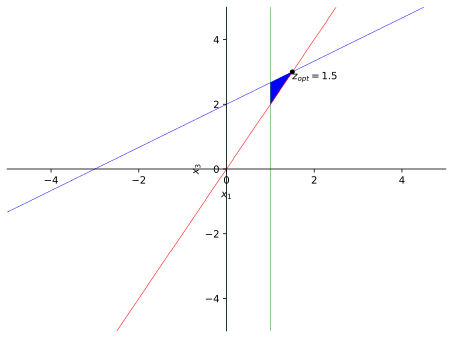

In [4]:
import sympy as sym

%config InlineBackend.figure_format = 'svg'
%matplotlib inline

# Declare symbolic variables
x1, x3 = sym.symbols('x1 x3')

# Plot feasible space and optimum
p = sym.plot_implicit(sym.And(x3 / 2 >= 0,  # urea constraint
                              1 - x1 <= 0,  # CO constraint
                              x1 - x3 / 2 <= 0,  # CO2 constraint
                              1 + x1 / 3 >= x3 / 2),  # H2/NH3 constraint
                      markers=[{"args": [[1.5], [3], "ko"],
                                "markersize": 4}],
                      annotations=[{'xy': (1.5, 3),
                                    'text': "$z_{opt}=1.5$",
                                    'ha': 'left',
                                    'va': 'top'}],
                      show=False)

# Plot constraint boundaries
peq_urea = sym.plot_implicit(
    sym.Eq(x3 / 2, 0),
    line_color='cyan',
    show=False
)
peq_co = sym.plot_implicit(
    sym.Eq(1 - x1, 0),
    line_color='green',
    show=False
)
peq_co2 = sym.plot_implicit(
    sym.Eq(x1 - x3 / 2, 0),
    line_color='red',
    show=False
)
peq_h2_nh3 = sym.plot_implicit(
    sym.Eq(1 + x1 / 3, x3 / 2),
    line_color='blue',
    show=False
)

p.append(peq_urea[0])
p.append(peq_co[0])
p.append(peq_co2[0])
p.append(peq_h2_nh3[0])

# Show and save final plot
p.show()
# p.save('urea_feasible_space.svg')

# If you would like to label the constraint lines, check out this discussion
# at Stack Overflow, especially the posts at the bottom of the page:
# https://stackoverflow.com/questions/72091742/graphing-inequalities-in-python

## Plotting LP Feasible Space on Desmos Within Jupyter

By invoking the Desmos graphing calculator within Jupyter, we can make interactive plots of LP feasible spaces.

In [5]:
import chbe444umd as des

expressions = [
    {'latex': 'x_1 = x', 'hidden': 'true'},
    {'latex': 'x_3 = y', 'hidden': 'true'},
    {'latex': 'x_3 / 2 >= 0', 'id': 'urea',
     'color': '#0000ff', 'fillOpacity': 0.2},
    {'latex': '1 - x_1 <= 0', 'id': 'co',
     'color': '#0000ff', 'fillOpacity': 0.2},
    {'latex': 'x_1 - x_3 / 2 <= 0', 'id': 'co2',
     'color': '#0000ff', 'fillOpacity': 0.2},
    {'latex': '1 + x_1 / 3 >= x_3 / 2', 'id': 'h2nh3',
     'color': '#0000ff', 'fillOpacity': 0.2},
    {'latex': '0 x_1 + x_3 / 2 = z', 'id': 'objective',
     'color': '#000000'}]

sliders = [{'variable': 'z', 'min': '0', 'max': '2', 'step': '0.1'}]

points = [{'latex': '(1.5, 3)', 'label': 'optimum', 'showLabel': True}]

graph_html = des.desmos_graph(
    expressions=expressions,
    sliders=sliders,
    points=points,
    axlim=[-0.5, 3.5, -0.5, 3.5],  # lower x, x span, lower y, y span
    size=[800, 600])  # size of the plot in Jupyter

# When calling desmos_graph, indicate blank expressions, sliders or points as
# empty arrays, e.g., sliders=[]

<IPython.core.display.Javascript object>

## Solving LPs with SciPy's `linprog`

SciPy offers many sophisticated optimization functions under `scipy.optimize`. One such function, `linprog`, solves LPs. To use `linprog`, we need to cast our LP in a matrix form:

$$
{\bf x} = 
\left[
\begin{array}{c}
x_1 \\ x_2 \\ \vdots \\
\end{array}
\right]
$$

$$
\begin{array}{ll}
\min  & z = {\bf c^T \cdot x} \\
s.t. & {\bf A_{ub} \cdot x} \leq {\bf b_{ub}} \\
     & {\bf A_{eq} \cdot x} \leq {\bf b_{eq}} \\
     & {\bf l} \leq {\bf x} \leq {\bf u}
\end{array}
$$

For the urea reaction path LP:

$$
{\bf x} = 
\left[
\begin{array}{c}
x_1 \\ x_3 \\
\end{array}
\right]
$$

$$
\begin{array}{lc}
\min  & z = {\bf c^T \cdot x} = [0 \ \ -\frac{1}{2}] \cdot 
\left[
\begin{array}{c}
x_1 \\ x_3 \\
\end{array}
\right] \\
      & \\
s.t. & 
       \left[ 
       \begin{array}{rr} 
       -1 & 0 \\ 
       1 & -\frac{1}{2} \\ 
       -\frac{1}{3} & \frac{1}{2} \\ 
       \end{array} 
       \right] \cdot 
       \left[
       \begin{array}{c}
       x_1 \\ x_3 \\
       \end{array}
       \right] 
       \leq 
       \left[
       \begin{array}{r}
       -1 \\ 0 \\ 1 \\
       \end{array}\\
       \right] \\
     & \\  
     & \left[
       \begin{array}{c}
       0 \\ 0 \\
       \end{array}
       \right] \leq 
       \left[
       \begin{array}{c}
       x_1 \\ x_3 \\
       \end{array}
       \right] \\
\end{array}
$$

In [6]:
import numpy as np
import scipy.optimize as opt

# Documentation for linprog is at:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linprog.html

c = [0, -0.5]  # objective function z = cT.x

# linprog is a minimization algorithm, and maximizing z is equivalent to
# minimizing -z

# See notes (on supplementary Jupyter notebook on GitHub) for how to handle
# scenarios involving maximization and constants in z

# Inequality constraints A_ub.x <= b_ub
A = [[-1, 0],
     [1, -1/2],
     [-1/3, 1/2]]

b = [-1, 0, 1]

res = opt.linprog(
     c,
     A_ub=A,
     b_ub=b,
     A_eq=None,
     b_eq=None,
     bounds=(0, None),
     method='highs'
     )

print(f"Coordinates of optimum: {res.x}")
print(f"Optimal function value: {-res.fun}")  # negate sign; we minimized z
print()
print(f"The optimum was z = {np.round(-res.fun, 4)} at x = {np.round(res.x, 4)}")
print(f"Was the optimization successful? {res.success}")

Coordinates of optimum: [1.5 3. ]
Optimal function value: 1.4999999999999998

The optimum was z = 1.5 at x = [1.5 3. ]
Was the optimization successful? True
